**Цель работы:** изучение алгоритмов кластеризации, приобретение навыков оценки качества разбиения данных на кластеры и интерпретации результатов.

**Постановка задачи:**
1. Загрузить датасет для задачи кластеризации / классификации (например, с платформы Kaggle). Провести дескриптивный анализ данных: определить размерность, типы признаков, наличие пропусков. Оценить распределение переменных (близость к нормальному) с использованием визуализации (гистограммы). Проверить условие применения кластеризации: отсутствие классов, осмысленность кластеризации, отсутствие выбросов.
2. Выполнить стандартизацию / нормализацию числовых признаков. Обосновать выбор метода масштабирования. Построить матрицу диаграмм рассеивания для визуальной оценки структуры данных, предположительного количества кластеров и типа кластерной структуры. Аргументировать выбор методов кластеризации на основе формы, размера и плотности кластеров.
3. Реализовать кластеризацию двумя различными методами на выбор: K-means (K-средних); иерархическая кластеризация; Иерархическая; EM-алгоритм (Gaussian Mixture). Для методов, требующих задания числа кластеров (K-means, иерархическая), подобрать оптимальное значение k с использованием: метода локтя и / или анализа силуэта.
4. Рассчитать метрики качества для обоих методов: внутренние и внешние. Оценить расстояние между кластерами, внутрикластерные расстояния, компактность кластеров, центры кластеров. Опционально, если известно разделение на классы, посчитать: индекс Rand, индекс Жаккара и др. внешние метрики. Привести содержательную интерпретацию полученных значений.
5. Исследовать влияние параметров одного из методов (например, ε и min_samples для Иерархическая или количества кластеров k для K-means) на качество кластеризации.
6. Визуализировать полученные кластеры в пространстве признаков (использовать PCA для снижения размерности при необходимости). Проанализировать центры кластеров (для K-means) и дать содержательную интерпретацию выделенных групп. Сравнить результаты, полученные двумя разными методами.

**Датасет:** Mall Customer Segmentation Data.<br>
Датасет предназначен для сегментации клиентов на основе их демографических и поведенческих данных. Цель — выявить однородные группы клиентов для разработки таргетированных маркетинговых стратегий, персонализированных предложений и оптимизации ресурсов.<br>
**Тип задачи:** Кластеризация.

**Признаки:**
- CustomerID (числовой) - уникальный идентификатор клиента;
- Gender (категориальный) - пол клиента (Male/Female); 
- Age (числовой) - возраст клиента;
- Annual Income (числовой) - годовой доход клиента в тысячах долларов;
- Spending Score (числовой) - оценка расходов, которая присваивается на основе анализа поведения клиента (частота покупок, суммы чеков, возвраты и т.д.). Шкала от 1 до 100, где 1 - низкие расходы, 100 - очень высокие.

In [176]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist

df_with_class = pd.read_csv('Mall_Customers.csv')

df = df_with_class.drop(columns=['CustomerID'])

print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
print(df.head())


Размер датасета: (200, 4)

Первые 5 строк:
   Gender  Age  Annual Income  Spending Score
0    Male   19             15              39
1    Male   21             15              81
2  Female   20             16               6
3  Female   23             16              77
4  Female   31             17              40


CustomerID не несет практической ценности для задачи, поэтому был исключен.

In [177]:
print('Количество пропущенных значений:\n', df.isnull().sum())

Количество пропущенных значений:
 Gender            0
Age               0
Annual Income     0
Spending Score    0
dtype: int64


Пропущенные значения в данных отсутствуют. Теперь проверим числовые признаки на наличие выбросов.

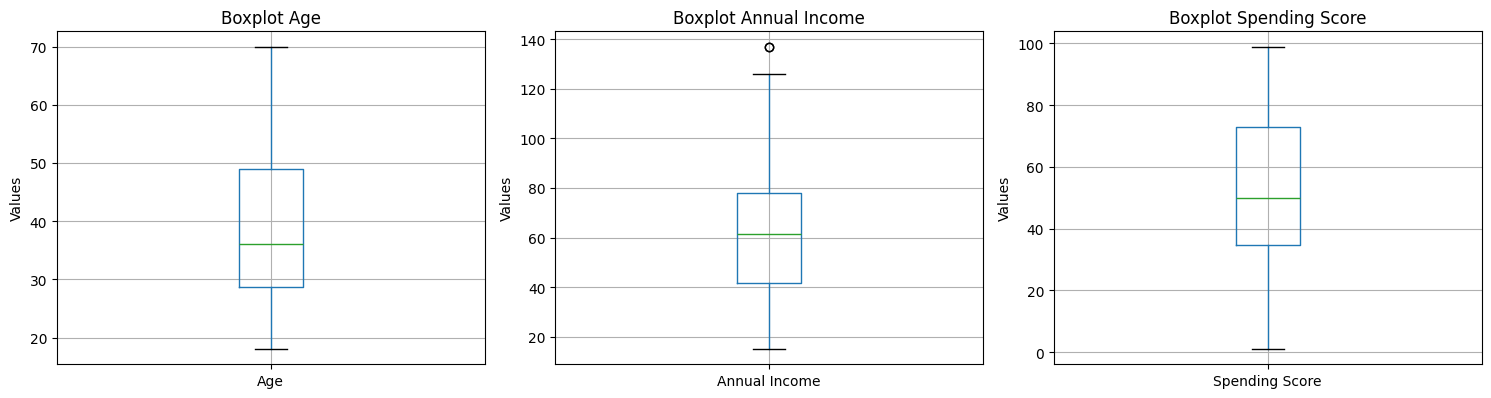

In [178]:
features = df.columns[1:]

fig, axes = plt.subplots(4, 4, figsize=(20, 15))
axes = axes.ravel()

for i, feature in enumerate(features):
    if i < len(axes):
        df.boxplot(column=feature, ax=axes[i])
        axes[i].set_title(f'Boxplot {feature}')
        axes[i].set_ylabel('Values')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

В результате построения ящиков с усами можно заметить, что признак Annual Income содержит выбросы. Можно попробовать избавиться от них, ограничив диапазон данных.

In [179]:
print(df[df["Annual Income"] > 130])

    Gender  Age  Annual Income  Spending Score
198   Male   32            137              18
199   Male   30            137              83


В Annual Income всего 2 выброса, что составляет всего 1% от исходных данных, поэтому можно просто исключить данные строки.

In [180]:
df = df.drop([198, 199])

print("Размер датасета:", df.shape)

Размер датасета: (198, 4)


В результате предобработки данных размер датасета сократился с 200 до 198 элементов (на 1%), что является приемлемым результатом.

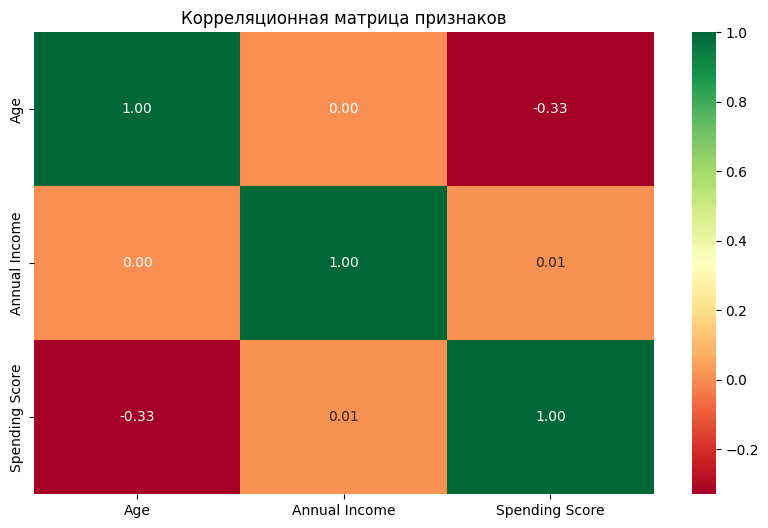

In [181]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[features].corr(), annot=True, cmap="RdYlGn", fmt=".2f")
plt.title("Корреляционная матрица признаков")
plt.show()

Значимые корреляции между переменными отсутствуют, значит, для кластеризации можно использовать все 3 признака.

In [182]:
print("Дескриптивный анализ:")

summary = pd.DataFrame({
    "Среднее": df[features].mean(numeric_only=True),
    "Медиана": df[features].median(numeric_only=True),
    "Мода": df[features].mode().iloc[0],
    "Ст. отклонение": df[features].std(numeric_only=True),
    "Мин": df[features].min(),
    "Макс": df[features].max()
})

print(summary.round(2))

Дескриптивный анализ:
                Среднее  Медиана  Мода  Ст. отклонение  Мин  Макс
Age               38.93     36.0  32.0           14.02   18    70
Annual Income     59.79     61.0  54.0           25.24   15   126
Spending Score    50.20     50.0  42.0           25.75    1    99


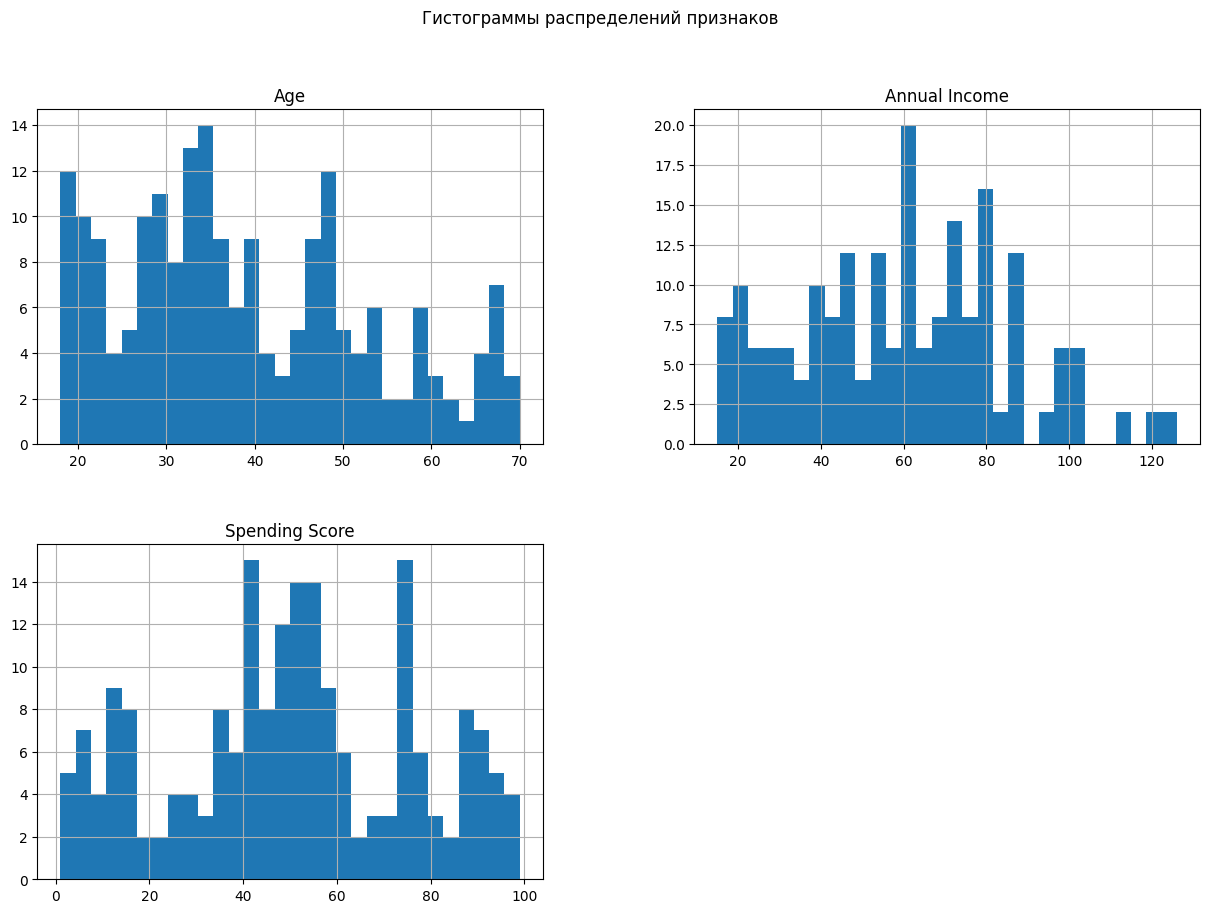

In [183]:
df.hist(bins=30, figsize=(15, 10))
plt.suptitle("Гистограммы распределений признаков")
plt.show()

Распределения признаков не согласуются с нормальным, кроме того, признаки представлены в разных единицах измерения, поэтому необходимо применить стандартизацию.

In [184]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])
df_scaled = pd.DataFrame(X_scaled, columns=df[features].columns)

print("Статистика после обработки:")
print(df_scaled.describe().round(2))

Статистика после обработки:
          Age  Annual Income  Spending Score
count  198.00         198.00          198.00
mean     0.00           0.00            0.00
std      1.00           1.00            1.00
min     -1.50          -1.78           -1.92
25%     -0.76          -0.77           -0.59
50%     -0.21           0.05           -0.01
75%      0.72           0.71            0.88
max      2.22           2.63            1.90


<Figure size 2000x2000 with 0 Axes>

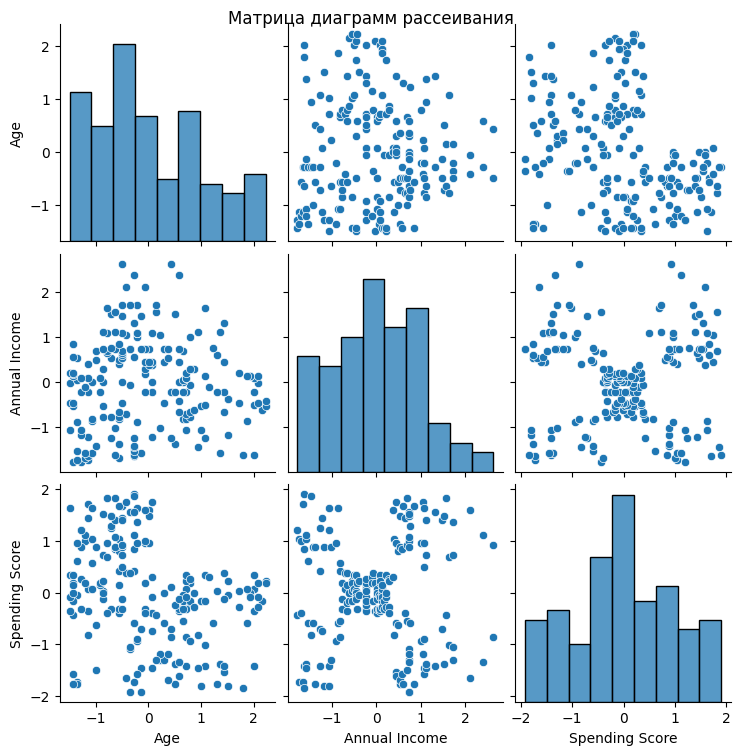

In [185]:
plt.figure(figsize=(20, 20))
sns.pairplot(df_scaled)
plt.suptitle('Матрица диаграмм рассеивания', y=1)
plt.show()

**Количество кластеров**<br>
Можно предположить, что оптимальное количество кластеров - 5. Это видно на диаграммах рассеивания Annual Income - Spending Score.<br>
На диаграммах Age - Spending Score выделяются 2 группы объектов.<br>
По диаграмм Age - Annual Income сложно делать какие-то выводы.<br>

**Форма и размеры**<br>
На диаграмме Annual Income - Spending Score видно, что кластеры примерно похожи на круги или овалы разных размеров с перемычками.<br>

**Выбор методов**<br>
Вероятно, алгоритм GMM подойдет для датасета, так как он позволяет моделировать кластеры различной формы и справляется с ситуациями, когда границы между кластерами нечеткие.<br>
Также можно использовать Иерархическую кластеризацию, так как она позволяет обнаруживать кластеры произвольной формы, датасет небольшого размера, и с помощью дендограммы удобно определять количество кластеров, если оно заранее неизвестно.<br>

Для алгоритма GMM нужно определить параметры n_components и covariance_type.<br>
covariance_type='full' указывает на то, что кластеры имеют разные формы, размеры и ориентацию, что подходит для представленных данных..<br>
Для выбора n_components есть практический метод – построение графика BIC.

Text(0.5, 1.0, 'BIC для выбора числа компонент')

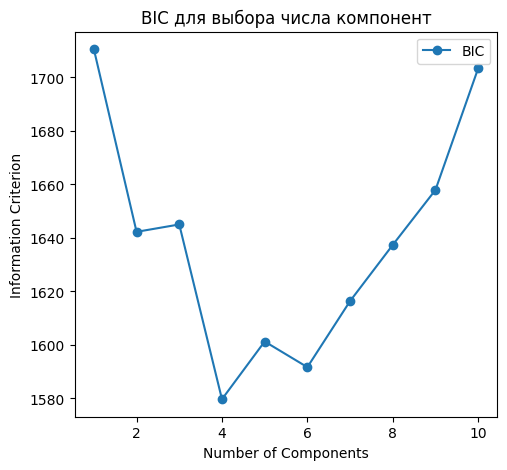

In [186]:
n_components_range = range(1, 11)
bics = []

for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=42)
    gmm.fit(X_scaled)
    bics.append(gmm.bic(X_scaled))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(n_components_range, bics, 'o-', label='BIC')
plt.xlabel('Number of Components')
plt.ylabel('Information Criterion')
plt.legend()
plt.title('BIC для выбора числа компонент')

BIC достигает минимума при n_components = 4. Это значит, что модель с 4 компонентами оптимальна. Дальнейшее увеличение числа компонент приводит к переобучению, а меньшее не улавливает всю структуру данных.

Для определения числа кластеров в иерархической кластеризации используется дендограмма, которая представлена далее. Также необходимо выбрать метрику расстояния и метод связи кластеров. Евклидово расстояние соответствует обычному прямолинейному расстоянию между точками в многомерном пространстве,
что интуитивно понятно и соответствует естественному восприятию близости клиентов по их характеристикам. Метод Уорда устойчив к шуму, создает сферические кластеры, поэтому можно выбрать его. 

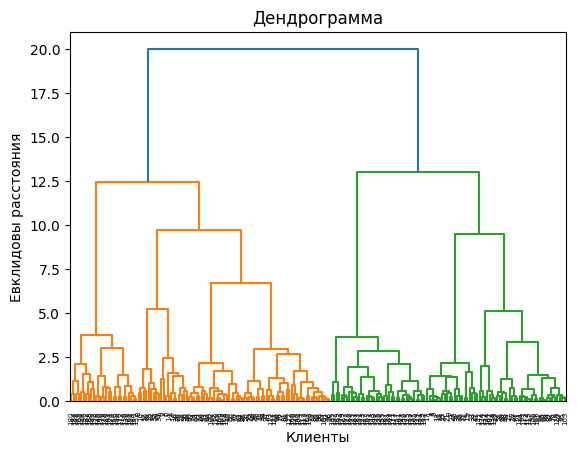

In [187]:
from scipy.cluster.hierarchy import dendrogram, linkage

dendrogram(linkage(X_scaled, method = "ward"))
plt.title('Дендрограмма')
plt.xlabel('Клиенты')
plt.ylabel('Евклидовы расстояния')
plt.show()


По дендограмме нужно найти самое большое вертикальное расстояние, которое можно пройти, не пересекая горизонтальные линии. Для этого набора данных оптимальным будет 6 кластеров.

In [188]:
from sklearn.cluster import AgglomerativeClustering 
hc = AgglomerativeClustering(n_clusters=6, linkage='ward')
hc_labels =hc.fit_predict(X_scaled)

gmm = GaussianMixture(n_components=4, covariance_type='full', n_init=10)
gmm_labels = gmm.fit_predict(X_scaled)

In [189]:
def calculate_cluster_metrics(X, labels, method_name):
    unique_labels = np.unique(labels)
    metrics = {}
    
    if len(unique_labels) > 1:
        metrics['silhouette'] = silhouette_score(X, labels)
        metrics['calinski_harabasz'] = calinski_harabasz_score(X, labels)
        metrics['davies_bouldin'] = davies_bouldin_score(X, labels)
    else:
        metrics['silhouette'] = metrics['calinski_harabasz'] = metrics['davies_bouldin'] = np.nan
    
    cluster_stats = {}
    for label in unique_labels:
        if label == -1:
            continue
            
        cluster_points = X[labels == label]
        if len(cluster_points) < 2:
            continue
            
        centroid = np.mean(cluster_points, axis=0)
        distances_to_center = np.linalg.norm(cluster_points - centroid, axis=1)
        
        cluster_stats[label] = {
            'size': len(cluster_points),
            'centroid': centroid,
            'compactness': np.mean(distances_to_center),
            'intra_mean': np.mean(pdist(cluster_points)),
            'radius': np.max(distances_to_center)
        }

    if len(cluster_stats) > 1:
        centroids = [stats['centroid'] for stats in cluster_stats.values()]
        inter_distances = pdist(centroids)
        metrics['mean_inter_distance'] = np.mean(inter_distances)
        metrics['min_inter_distance'] = np.min(inter_distances)
    else:
        metrics['mean_inter_distance'] = metrics['min_inter_distance'] = np.nan
    
    return metrics, cluster_stats
hc_metrics, hc_stats = calculate_cluster_metrics(X_scaled, hc_labels, "Иерархическая")
gmm_metrics, gmm_stats = calculate_cluster_metrics(X_scaled, gmm_labels, "GMM")

print("Внутренние метрики качества кластеризации")
metrics_comparison = pd.DataFrame({
    'Метод': ['Иерархическая', 'GMM'],
    'Кластеры': [len(hc_stats), len(gmm_stats)],
    'Silhouette': [
        f"{hc_metrics['silhouette']:.4f}" if not np.isnan(hc_metrics['silhouette']) else 'N/A',
        f"{gmm_metrics['silhouette']:.4f}" if not np.isnan(gmm_metrics['silhouette']) else 'N/A'
    ],
    'Calinski-Harabasz': [
        f"{hc_metrics['calinski_harabasz']:.2f}" if not np.isnan(hc_metrics['calinski_harabasz']) else 'N/A',
        f"{gmm_metrics['calinski_harabasz']:.2f}" if not np.isnan(gmm_metrics['calinski_harabasz']) else 'N/A'
    ],
    'Davies-Bouldin': [
        f"{hc_metrics['davies_bouldin']:.4f}" if not np.isnan(hc_metrics['davies_bouldin']) else 'N/A',
        f"{gmm_metrics['davies_bouldin']:.4f}" if not np.isnan(gmm_metrics['davies_bouldin']) else 'N/A'
    ]
})

print(metrics_comparison.to_string(index=False))

def analyze_clusters_structure(X, labels, method_name):
    metrics, cluster_stats = calculate_cluster_metrics(X, labels, method_name)
    
    print(f"\nАнализ структуры кластеров {method_name}")
    cluster_analysis = []
    for label, stats in cluster_stats.items():
        cluster_analysis.append({
            'Кластер': label,
            'Размер': stats['size'],
            'Доля, %': f"{(stats['size'] / len(X) * 100):.1f}",
            'Компактность': f"{stats['compactness']:.4f}",
            'Внутр. расстояние': f"{stats['intra_mean']:.4f}",
            'Радиус': f"{stats['radius']:.4f}"
        })
    
    cluster_df = pd.DataFrame(cluster_analysis)
    print(cluster_df.to_string(index=False))
    
    if not np.isnan(metrics['mean_inter_distance']):
        print(f"\nСреднее межкластерное расстояние: {metrics['mean_inter_distance']:.4f}")
        print(f"Минимальное межкластерное расстояние: {metrics['min_inter_distance']:.4f}")
    
    return cluster_stats, metrics

hc_stats, hc_metrics = analyze_clusters_structure(X_scaled, hc_labels, "Иерархическая")
gmm_stats, gmm_metrics = analyze_clusters_structure(X_scaled, gmm_labels, "GMM")

Внутренние метрики качества кластеризации
        Метод  Кластеры Silhouette Calinski-Harabasz Davies-Bouldin
Иерархическая         6     0.4259            124.89         0.8446
          GMM         4     0.3784            108.03         0.9886

Анализ структуры кластеров Иерархическая
 Кластер  Размер Доля, % Компактность Внутр. расстояние Радиус
       0      57    28.8       0.8017            1.1192 1.5330
       1      20    10.1       0.9851            1.4058 1.9782
       2      38    19.2       0.6608            0.9283 1.6517
       3      27    13.6       0.8211            1.1718 1.5133
       4      35    17.7       0.7454            1.0647 1.8595
       5      21    10.6       0.5491            0.7898 1.0649

Среднее межкластерное расстояние: 2.4486
Минимальное межкластерное расстояние: 1.7850

Анализ структуры кластеров GMM
 Кластер  Размер Доля, % Компактность Внутр. расстояние Радиус
       0      50    25.3       0.9691            1.3102 1.8685
       1      34    17.2  

**Сравнение методов:**<br>
На основании полученных метрик качества, иерархическая кластеризация показывает лучшие результаты для данного набора данных, чем GMM.
- Silhouette: Более высокий показатель у иерархической кластеризации указывает на то, что объекты в кластерах лучше сгруппированы и сильнее отделены от других кластеров.
- Calinski-Harabasz: Более высокий показатель у иерархической кластеризации подтверждает, что кластеры более плотные и хорошо разделены.
- Davies-Bouldin: Более низкий показатель у иерархической кластеризации свидетельствует о лучшей компактности кластеров и их лучшем разделении.

**Анализ кластеров иерархической кластеризации:**
- Кластер 2: Наиболее компактный кластер с хорошей плотностью, но самый маленький (10.6% данных).
- Кластер 0: Крупнейший кластер (28.8% данных) с хорошей компактностью (0.8017) и умеренным внутренним расстоянием (1.1192).
- Кластер 1: Самый разреженный кластер (компактность 0.9851), несмотря на небольшой размер (10.1% данных), требует дополнительного анализа.
- Кластер 3 и 4: Средние по размеру кластеры (13.6% и 17.7%) с хорошими показателями компактности.
Минимальное межкластерное расстояние = 1.7850 - это умеренное значение указывает на достаточно хорошее разделение кластеров, при этом они не слишком разнесены в пространстве. Среднее межкластерное расстояние = 2.4486 подтверждает сбалансированное распределение кластеров.

**Анализ кластеров GMM:**
- Кластер 2: Крупнейший кластер (38.4% данных) с наименьшей компактностью (1.1047) и наибольшим радиусом (2.8092), что указывает на его неоднородность.
- Кластер 0: Наиболее компактный кластер (0.6608) среди GMM, но имеет средний размер (19.2%).
- Кластер 1 и 3: Средние кластеры (17.2% и 25.3%) с умеренными показателями компактности.
Минимальное межкластерное расстояние = 1.9216 - несколько выше, чем у иерархической кластеризации, но в сочетании с более низкими значениями silhouette и calinski-harabasz это указывает на менее оптимальное разделение. Среднее расстояние = 2.3108 также ниже, чем у иерархического метода.


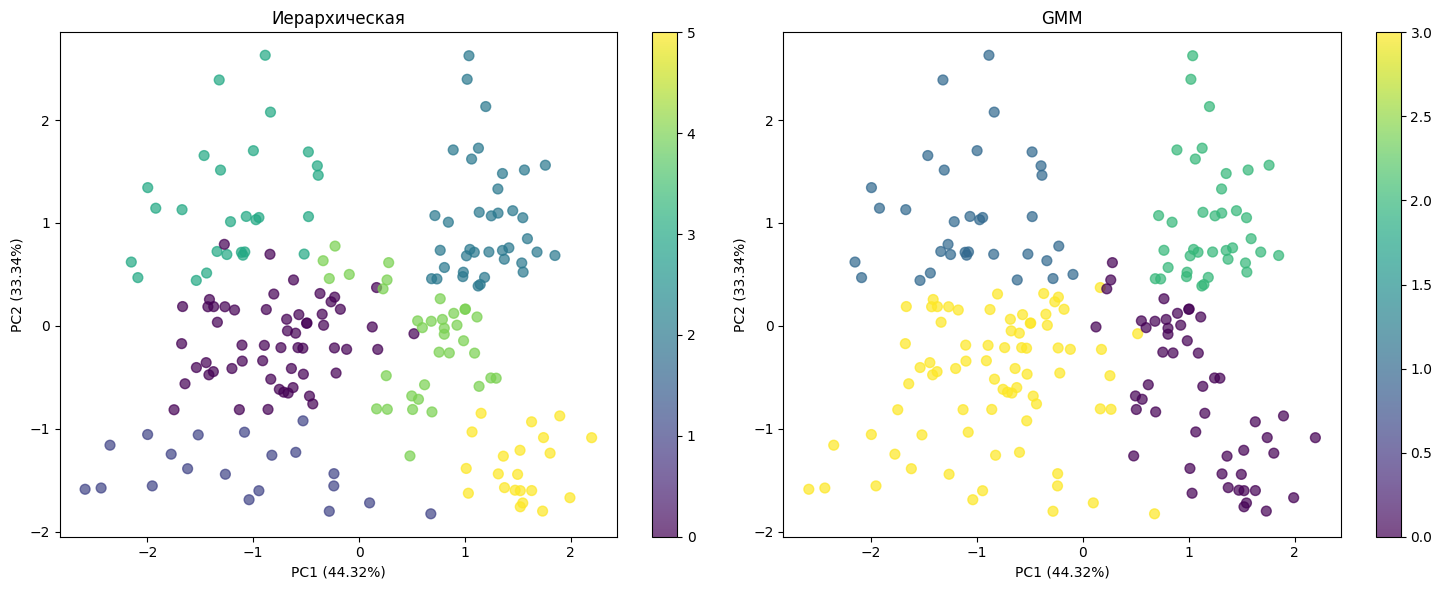

In [190]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=hc_labels, cmap='viridis', alpha=0.7, s=50)
axes[0].set_title('Иерархическая')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')

plt.colorbar(scatter1, ax=axes[0])

scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels, cmap='viridis', alpha=0.7, s=50)
axes[1].set_title('GMM')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')

plt.colorbar(scatter2, ax=axes[1])

plt.tight_layout()
plt.show()

In [191]:
gmm_centers = gmm.means_

scaler.fit(df[df.columns[1:]])
gmm_centers_original = scaler.inverse_transform(gmm_centers)

print("Центры кластеров GMM")
gmm_centers_analysis = []
for i, center in enumerate(gmm_centers_original):
    cluster_size = np.sum(gmm_labels == i)
    center_info = {'Кластер': i, 'Размер': cluster_size}
    center_info['Age'] = f"{center[0]:.2f}"
    center_info['Annual Income'] = f"{center[1]:.2f}" 
    center_info['Spending Score'] = f"{center[2]:.2f}"
    gmm_centers_analysis.append(center_info)

gmm_centers_df_detailed = pd.DataFrame(gmm_centers_analysis)
print(gmm_centers_df_detailed.to_string(index=False))

Центры кластеров GMM
 Кластер  Размер   Age Annual Income Spending Score
       0      50 24.52         43.45          62.42
       1      34 42.14         86.93          17.29
       2      38 32.70         85.31          82.13
       3      76 49.86         46.15          41.03


**Анализ центров кластеров GMM**<br>
- Кластер 0: Люди среднего возраста с достаточно высоким доходом (2 место по доходу) и самыми высокими расходами. Целевая аудитория для премиальных товаров и новых коллекций.
- Кластер 1: Взрослые люди с высоким доходом и самыми низкими расходами. Рациональные покупатели, ценящие качество, но не склонные к импульсивным покупкам.
- Кластер 2: Самые старшие из представленных со средними доходами и расходами. Самый многочисленный сегмент. Клиенты предпенсионного возраста - консервативные покупатели, ориентированные на необходимость.
- Кластер 3: Самые молодые, самый низкий доход и вторые по величине расходы. Молодые клиенты с низким доходом, но активно тратящие деньги. Склонны к импульсивным покупкам, ориентированы на тренды и доступные цены.

In [ ]:
df['cluster_hierarchical'] = hc_labels

print("Средние значения кластеров иерархической кластеризации:")

hierarchical_means = df.groupby('cluster_hierarchical')[['Age', 'Annual Income', 'Spending Score']].mean()
hierarchical_sizes = df['cluster_hierarchical'].value_counts().sort_index()

hierarchical_summary = pd.DataFrame({
    'Кластер': hierarchical_means.index,
    'Размер': hierarchical_sizes.values,
    'Age': hierarchical_means['Age'].round(1).values,
    'Annual Income': hierarchical_means['Annual Income'].round(1).values,
    'Spending Score': hierarchical_means['Spending Score'].round(1).values
})

print(hierarchical_summary.to_string(index=False))

Центры кластеров иерархической кластеризации:
 Кластер  Размер  Age  Annual Income  Spending Score
       0      57 53.0           55.3            47.9
       1      20 43.9           24.4            19.1
       2      38 32.8           85.2            82.1
       3      27 44.3           89.6            16.6
       4      35 24.1           57.1            45.0
       5      21 24.8           25.6            80.2


**Анализ кластеров иерархической кластеризации:**
- Кластер 0: Самый крупный сегмент. Клиенты предпенсионного возраста с умеренным доходом и консервативными тратами. Рациональные покупатели, ориентированные на необходимость и качество.
- Кластер 1: Маленькая группа. Клиенты среднего возраста с очень низким доходом и минимальными расходами. Возможно, находятся в сложной финансовой ситуации.
- Кластер 2: Молодые люди с высоким доходом и активным потреблением. Целевая аудитория для премиальных товаров и новых коллекций.
- Кластер 3: Парадоксальная группа. Клиенты с максимальным доходом, но минимальными расходами. Рациональные инвесторы или сберегатели, не склонные к импульсивным покупкам.
- Кластер 4: Перспективный сегмент. Молодые специалисты с хорошим стартовым доходом. Потенциальные клиенты для формирования лояльности.
- Кластер 5: Еще один интересный парадокс. Молодые клиенты с низким доходом, но максимальными тратами. Склонны к импульсивным покупкам, живут "от зарплаты до зарплаты".

Сравнительная таблица метрик качества кластеризации GMM
 Компоненты Тип ковариации Silhouette Calinski-Harabasz Davies-Bouldin Ср. межкл. расст. Мин. межкл. расст.
          4      spherical     0.4053            122.87         0.9269            2.2874             1.9362
          4           diag     0.2685             63.08         1.3943            2.1560             1.5725
          4           tied     0.4033            123.35         0.9269            2.2653             1.8857
          4           full     0.2626             62.18         1.3982            2.1448             1.4745
          5      spherical     0.4055            121.30         0.8771            2.4173             1.8096
          5           diag     0.3495             82.89         1.1249            2.4293             1.6113
          5           tied     0.4099            122.81         0.8694            2.3686             1.6444
          5           full     0.4104            117.74         0.9270          

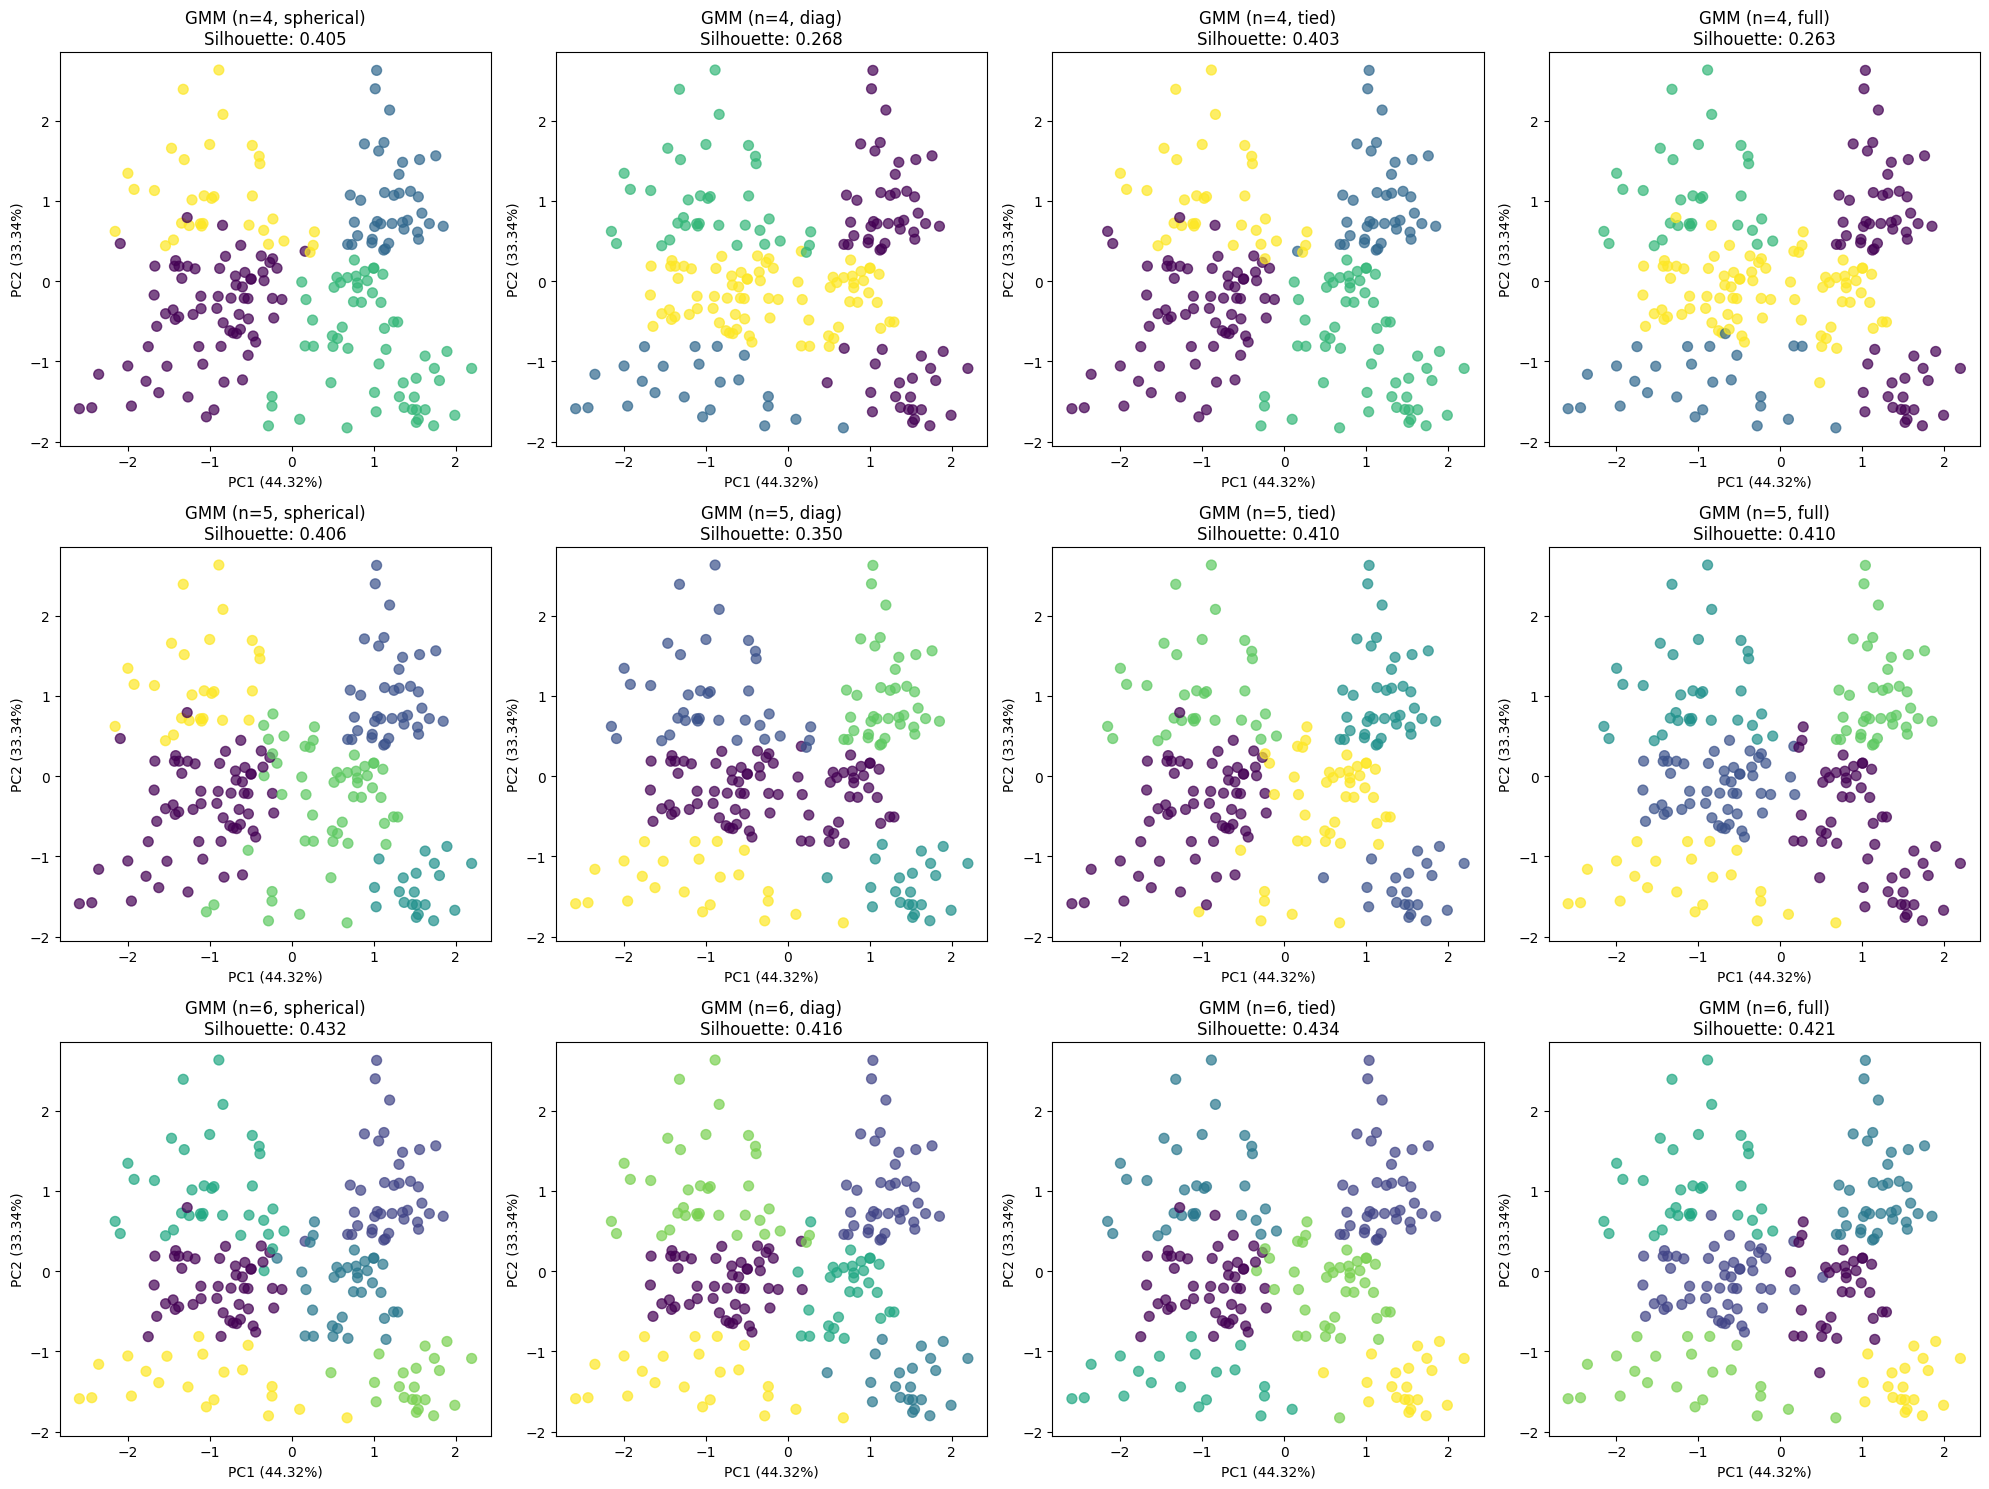

In [193]:
results_gmm = []

for n_components in range(4, 7):
    for cov_type in ['spherical', 'diag', 'tied', 'full']:
        try:
            gmm = GaussianMixture(
                n_components=n_components, 
                covariance_type=cov_type, 
                n_init=10,
                random_state=42
            )
            gmm_labels = gmm.fit_predict(X_scaled)
            
            metrics = {}
            if len(np.unique(gmm_labels)) > 1:
                metrics['silhouette'] = silhouette_score(X_scaled, gmm_labels)
                metrics['calinski_harabasz'] = calinski_harabasz_score(X_scaled, gmm_labels)
                metrics['davies_bouldin'] = davies_bouldin_score(X_scaled, gmm_labels)
            else:
                metrics['silhouette'] = metrics['calinski_harabasz'] = metrics['davies_bouldin'] = np.nan
            
            cluster_stats = {}
            for label in np.unique(gmm_labels):
                cluster_points = X_scaled[gmm_labels == label]
                centroid = np.mean(cluster_points, axis=0)
                distances_to_center = np.linalg.norm(cluster_points - centroid, axis=1)
                
                cluster_stats[label] = {
                    'size': len(cluster_points),
                    'compactness': np.mean(distances_to_center),
                    'intra_mean': np.mean(pdist(cluster_points)) if len(cluster_points) > 1 else 0,
                    'radius': np.max(distances_to_center)
                }
            
            centroids = gmm.means_
            inter_distances = pdist(centroids)
            
            results_gmm.append({
                'n_components': n_components,
                'covariance_type': cov_type,
                'silhouette': metrics['silhouette'],
                'calinski_harabasz': metrics['calinski_harabasz'],
                'davies_bouldin': metrics['davies_bouldin'],
                'mean_inter_distance': np.mean(inter_distances),
                'min_inter_distance': np.min(inter_distances),
                'labels': gmm_labels,
                'model': gmm
            })
            
        except Exception as e:
            print(f"Ошибка для n_components={n_components}, cov_type={cov_type}: {e}")
            continue

comparison_gmm_df = pd.DataFrame({
    'Компоненты': [result['n_components'] for result in results_gmm],
    'Тип ковариации': [result['covariance_type'] for result in results_gmm],
    'Silhouette': [f"{result['silhouette']:.4f}" for result in results_gmm],
    'Calinski-Harabasz': [f"{result['calinski_harabasz']:.2f}" for result in results_gmm],
    'Davies-Bouldin': [f"{result['davies_bouldin']:.4f}" for result in results_gmm],
    'Ср. межкл. расст.': [f"{result['mean_inter_distance']:.4f}" for result in results_gmm],
    'Мин. межкл. расст.': [f"{result['min_inter_distance']:.4f}" for result in results_gmm]
})

print("Сравнительная таблица метрик качества кластеризации GMM")
print(comparison_gmm_df.to_string(index=False))

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.ravel()

for i, result in enumerate(results_gmm):
    if i < len(axes):
        scatter = axes[i].scatter(X_pca[:, 0], X_pca[:, 1], c=result['labels'], 
                                 cmap='viridis', alpha=0.7, s=50)
        axes[i].set_title(f'GMM (n={result["n_components"]}, {result["covariance_type"]})\nSilhouette: {result["silhouette"]:.3f}')
        axes[i].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
        axes[i].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')

for j in range(len(results_gmm), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Анализ влияния количества компонент и типа ковариации в методе Gaussian Mixture Models показал следующие закономерности:
1. С увеличением числа компонент от 4 до 6 наблюдается последовательное улучшение метрик качества. Наивысшие значения достигаются при 6 компонентах.
2. Типы 'spherical' и 'tied' демонстрируют лучшие результаты по сравнению с 'diag' и 'full', что указывает на сферическую форму кластеров в данных.

GMM с 6 компонентами и tied ковариацией обеспечивает наилучшее качество сегментации, немного превосходя иерархическую кластеризацию. Результат получается также лучше первоначального разбиения.